# Unemployment Analysis with Python

## OIBSIP Data Science Internship - Task 2

## Introduction

Unemployment is an important economic indicator that reflects the availability of employment opportunities within a population.

In this project, the unemployment dataset for India is analyzed using Python. The analysis focuses on regional differences, monthly trends, relationships between employment indicators, and changes between the Pre-COVID and Post-COVID periods.

The project uses Python libraries including Pandas, NumPy, Matplotlib and Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import os
print(os.getcwd())

c:\Users\talar\OneDrive\Desktop\OIBSIP\DataScience-Task1-IrisClassification\DataScience-Task2-UnemploymentAnalysis


In [3]:
import os
print(os.listdir())

['Unemployment in India.csv', 'unemployment_analysis.ipynb']


In [4]:
import pandas as pd

df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 7


In [7]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [9]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


## Data Loading and Initial Inspection

The unemployment dataset was loaded using Pandas.

The dataset was inspected to understand its dimensions, column names, data types, and missing values. These initial checks are important before performing exploratory data analysis because they help identify data-quality issues and determine the appropriate preprocessing steps.

In [10]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [11]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [12]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 7


In [13]:
df[df.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [15]:
df = df.dropna(how="all")

In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 740
Columns: 7


In [17]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [18]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [19]:
print(df.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object


## Data Cleaning

The dataset initially contained 768 rows, including 28 completely empty rows. These empty rows were removed because they did not contain any useful information.

After cleaning, the dataset contains 740 valid observations and 7 columns.

The column names were stripped of unnecessary spaces, and the Date column was converted from string format to datetime format. This conversion is necessary for performing time-series analysis and comparing unemployment rates before and after the COVID-19 period.


In [20]:
print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.2 KB


In [22]:
df = df.reset_index(drop=True)

print(df.shape)
print(df.head())

(740, 7)
           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  


In [23]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

print(region_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


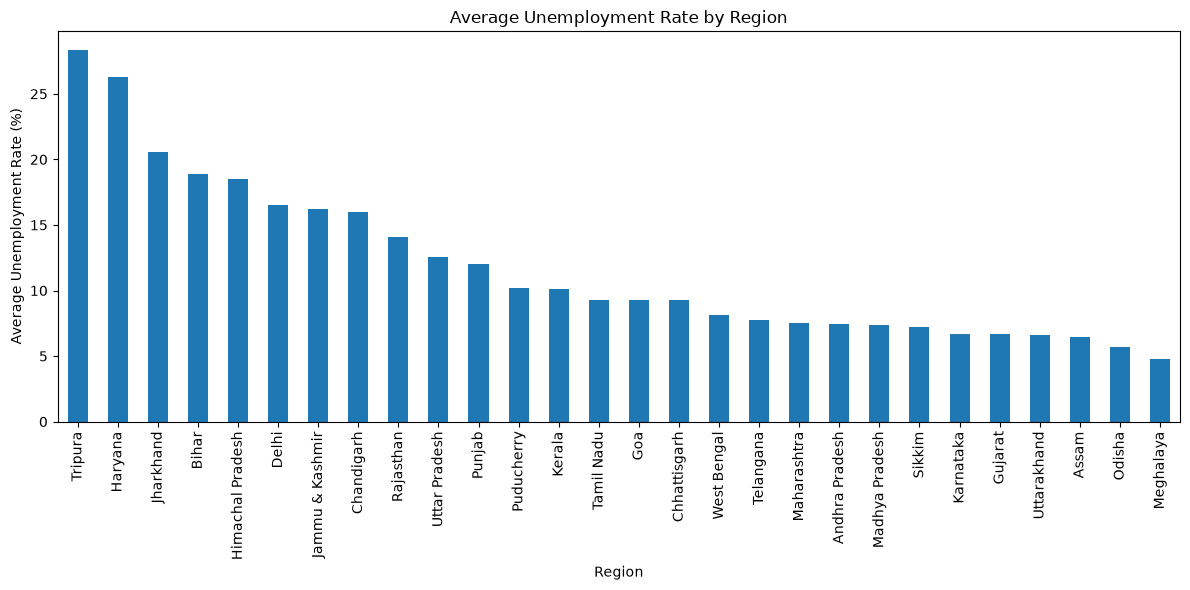

In [24]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observation

The bar chart shows the average unemployment rate across different regions of India.

Tripura and Haryana have the highest average unemployment rates in the dataset, while Meghalaya and Odisha have relatively lower average unemployment rates.

This shows that unemployment was not evenly distributed across regions during the period covered by the dataset.

In [25]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

print(df[["Date", "Month", "Year"]].head())

        Date  Month  Year
0 2019-05-31      5  2019
1 2019-06-30      6  2019
2 2019-07-31      7  2019
3 2019-08-31      8  2019
4 2019-09-30      9  2019


In [26]:
monthly_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

print(monthly_avg)

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


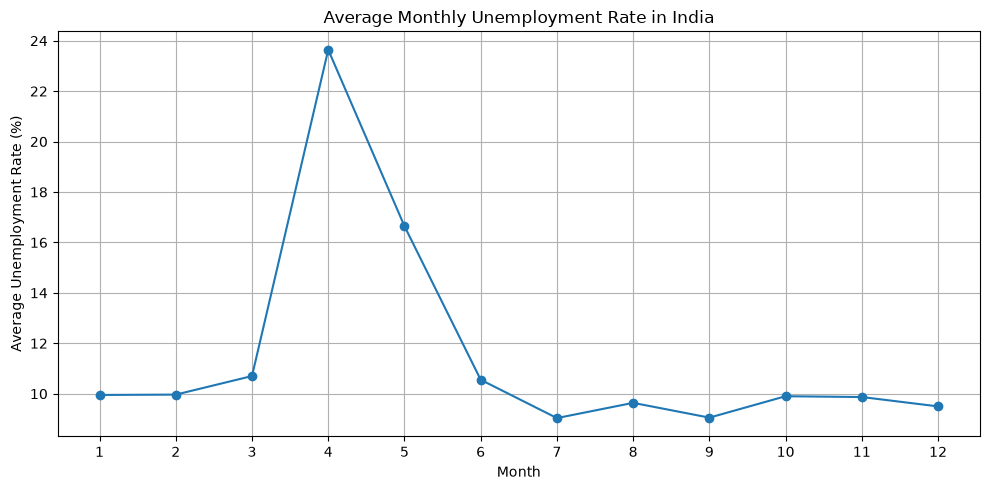

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Monthly Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The month-wise analysis shows that unemployment rates varied considerably across different months.

The average unemployment rate reached its highest level in April, followed by a sharp decline during May and June.

From July onwards, the unemployment rate remained relatively stable with small monthly fluctuations.

This indicates that unemployment levels changed significantly during certain periods of the year.

In [28]:
print(df["Region"].unique())

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str


In [29]:
print(df["Region"].unique())

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str


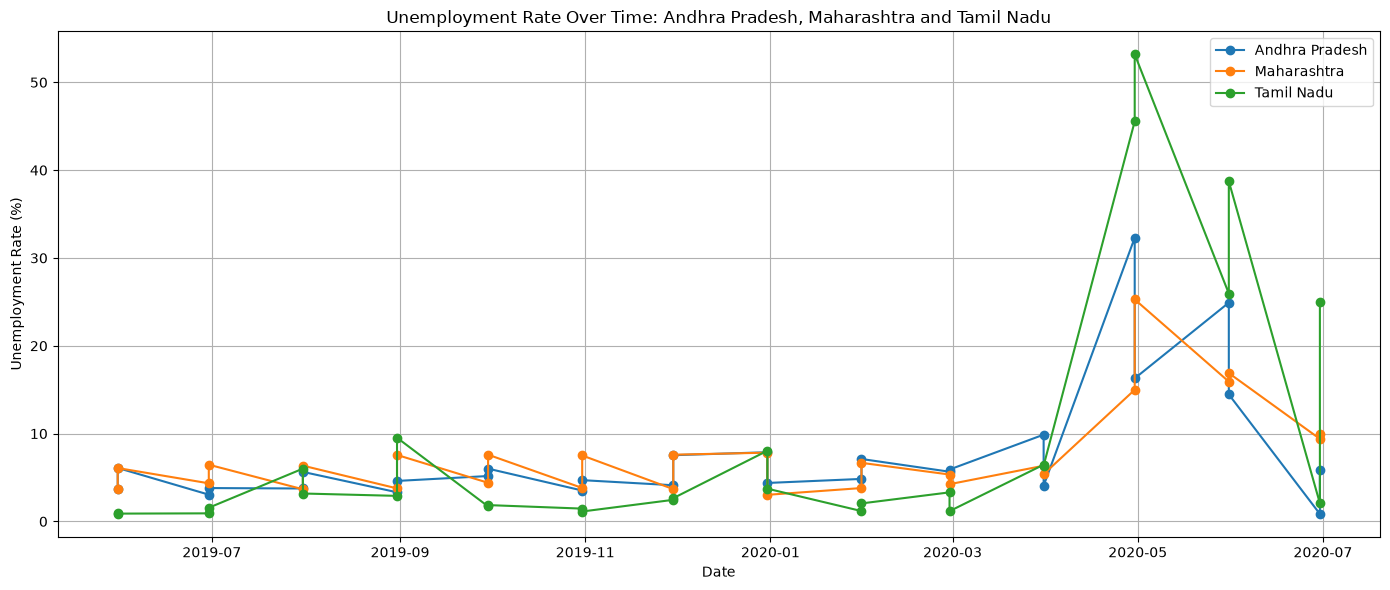

In [30]:
selected_regions = ["Andhra Pradesh", "Maharashtra", "Tamil Nadu"]

plt.figure(figsize=(14, 6))

for region in selected_regions:
    region_data = df[df["Region"] == region].sort_values("Date")
    
    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time: Andhra Pradesh, Maharashtra and Tamil Nadu")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The time-series chart compares unemployment rates in Andhra Pradesh, Maharashtra and Tamil Nadu over the period covered by the dataset.

The unemployment rates fluctuate over time, and the three regions show different patterns.

A noticeable increase in unemployment can be observed during the period associated with the COVID-19 pandemic, followed by a decline in subsequent months.

The comparison shows that unemployment trends differed across regions.

In [31]:
top_10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


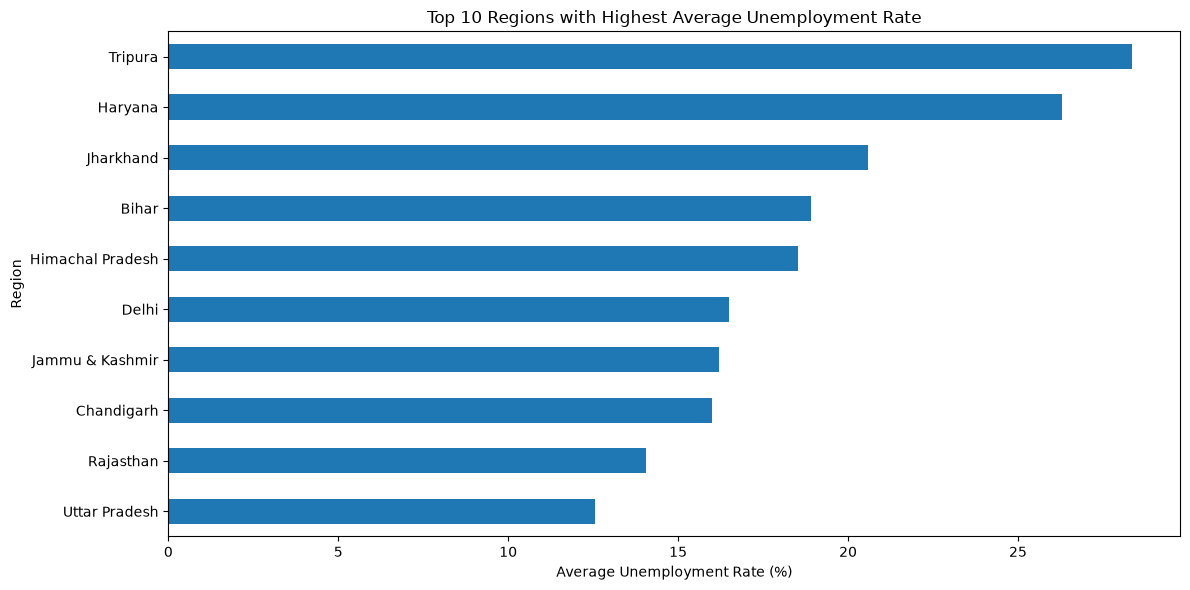

In [32]:
plt.figure(figsize=(12, 6))

top_10.sort_values().plot(kind="barh")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

The bar chart presents the top 10 regions with the highest average unemployment rates.

Tripura and Haryana are among the regions with the highest average unemployment rates in the dataset.

The chart highlights the regions that experienced comparatively higher unemployment during the period studied.

In [33]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


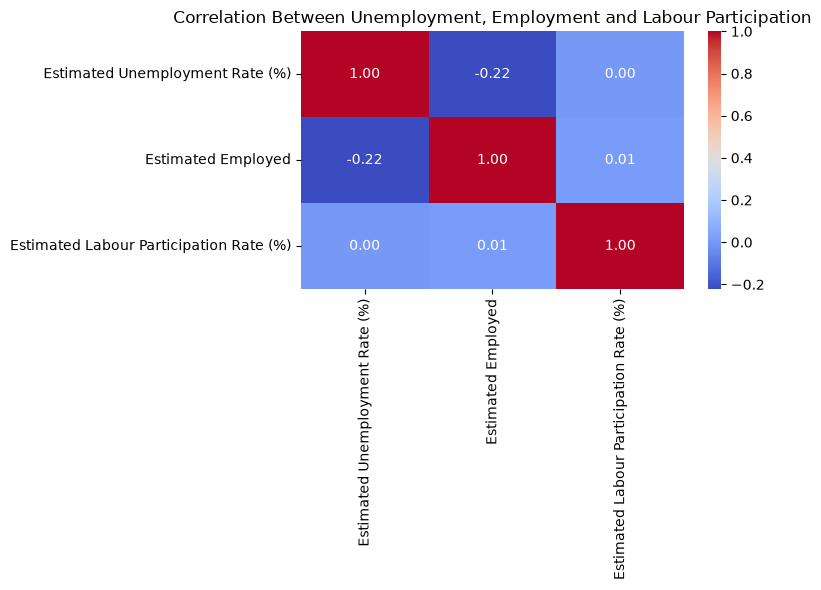

In [34]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Unemployment, Employment and Labour Participation")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between unemployment rate, estimated employment and labour participation rate.

The unemployment rate has a weak negative correlation with estimated employment, with a correlation value of approximately -0.22.

The correlation between unemployment rate and labour participation rate is approximately 0.00, indicating almost no linear relationship in this dataset.

The correlation between estimated employment and labour participation rate is also very weak, with a value of approximately 0.01.

Correlation measures association between variables and does not imply causation.

In [35]:
covid_date = pd.Timestamp("2020-03-01")

df["COVID_Period"] = np.where(
    df["Date"] < covid_date,
    "Pre-COVID",
    "Post-COVID"
)

print(df[["Date", "COVID_Period"]].head())

        Date COVID_Period
0 2019-05-31    Pre-COVID
1 2019-06-30    Pre-COVID
2 2019-07-31    Pre-COVID
3 2019-08-31    Pre-COVID
4 2019-09-30    Pre-COVID


In [36]:
covid_comparison = df.groupby("COVID_Period")[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

print(covid_comparison)

              Estimated Unemployment Rate (%)  Estimated Employed  \
COVID_Period                                                        
Post-COVID                          17.774363        6.517203e+06   
Pre-COVID                            9.509534        7.466028e+06   

              Estimated Labour Participation Rate (%)  
COVID_Period                                           
Post-COVID                                  39.330049  
Pre-COVID                                   43.886119  


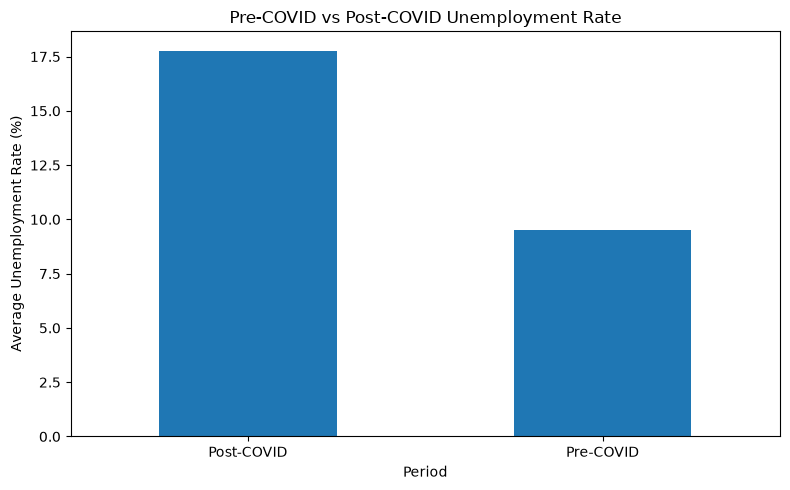

In [37]:
covid_rates = df.groupby("COVID_Period")[
    "Estimated Unemployment Rate (%)"
].mean()

plt.figure(figsize=(8, 5))

covid_rates.plot(kind="bar")

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The comparison shows a significant difference between the Pre-COVID and Post-COVID periods.

The average unemployment rate was approximately 9.4% during the Pre-COVID period and increased to approximately 17.8% during the Post-COVID period.

This indicates a substantial rise in unemployment during the period associated with the COVID-19 pandemic.

The comparison suggests that the pandemic period was associated with a major disruption in employment conditions.

In [38]:
covid_comparison

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
COVID_Period,,,
Post-COVID,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


## Pre-COVID vs Post-COVID Comparison

The following table compares the average unemployment rate, estimated employment and labour participation rate between the Pre-COVID and Post-COVID periods.

## Key Findings

- Tripura had the highest average unemployment rate among the regions analyzed, followed by Haryana and Jharkhand.
- The monthly analysis showed that the unemployment rate reached its highest average level in April.
- Andhra Pradesh, Maharashtra and Tamil Nadu showed noticeable fluctuations in unemployment over time.
- The correlation analysis showed a weak negative relationship between unemployment rate and estimated employment, with a correlation of approximately -0.22.
- The average unemployment rate increased from 9.51% in the Pre-COVID period to 17.77% in the Post-COVID period.
- Estimated employment decreased from approximately 7.47 million in the Pre-COVID period to 6.52 million in the Post-COVID period.
- Labour participation decreased from approximately 43.89% to 39.33% between the Pre-COVID and Post-COVID periods.

## Conclusion

The analysis shows significant differences in unemployment rates across regions and months.

Tripura, Haryana and Jharkhand recorded some of the highest average unemployment rates in the dataset. The monthly analysis also showed considerable fluctuations in unemployment.

The correlation analysis showed a weak negative relationship between unemployment rate and estimated employment, while the relationships involving labour participation were very weak.

The Pre-COVID and Post-COVID comparison showed a substantial increase in average unemployment, together with decreases in estimated employment and labour participation during the Post-COVID period.

Overall, the analysis demonstrates how exploratory data analysis and visualization can be used to understand unemployment patterns in India.